In [2]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import numpy as np

In [10]:
DATA_DIR = Path("../data/raw/kaggle_3m")

patient_folders = [f for f in DATA_DIR.iterdir() if f.is_dir()]

print(f"Total number of patients: {len(patient_folders)}")
print(f"Some examples of folder names: {[f.name for f in patient_folders[:3]]}")

Total number of patients: 110
Some examples of folder names: ['TCGA_CS_4941_19960909', 'TCGA_CS_4942_19970222', 'TCGA_CS_4943_20000902']


In [11]:
sample_patient = patient_folders[0]
sample_files = sorted(os.listdir(sample_patient))

print(f"Sample folder: {sample_patient.name}")
print(f"Number of files: {len(sample_files)}")
for f in sample_files:
    print(f)

Sample folder: TCGA_CS_4941_19960909
Number of files: 46
TCGA_CS_4941_19960909_1.tif
TCGA_CS_4941_19960909_10.tif
TCGA_CS_4941_19960909_10_mask.tif
TCGA_CS_4941_19960909_11.tif
TCGA_CS_4941_19960909_11_mask.tif
TCGA_CS_4941_19960909_12.tif
TCGA_CS_4941_19960909_12_mask.tif
TCGA_CS_4941_19960909_13.tif
TCGA_CS_4941_19960909_13_mask.tif
TCGA_CS_4941_19960909_14.tif
TCGA_CS_4941_19960909_14_mask.tif
TCGA_CS_4941_19960909_15.tif
TCGA_CS_4941_19960909_15_mask.tif
TCGA_CS_4941_19960909_16.tif
TCGA_CS_4941_19960909_16_mask.tif
TCGA_CS_4941_19960909_17.tif
TCGA_CS_4941_19960909_17_mask.tif
TCGA_CS_4941_19960909_18.tif
TCGA_CS_4941_19960909_18_mask.tif
TCGA_CS_4941_19960909_19.tif
TCGA_CS_4941_19960909_19_mask.tif
TCGA_CS_4941_19960909_1_mask.tif
TCGA_CS_4941_19960909_2.tif
TCGA_CS_4941_19960909_20.tif
TCGA_CS_4941_19960909_20_mask.tif
TCGA_CS_4941_19960909_21.tif
TCGA_CS_4941_19960909_21_mask.tif
TCGA_CS_4941_19960909_22.tif
TCGA_CS_4941_19960909_22_mask.tif
TCGA_CS_4941_19960909_23.tif
TCGA_C

Unique values ​​of clipping mask 15: [  0 255]


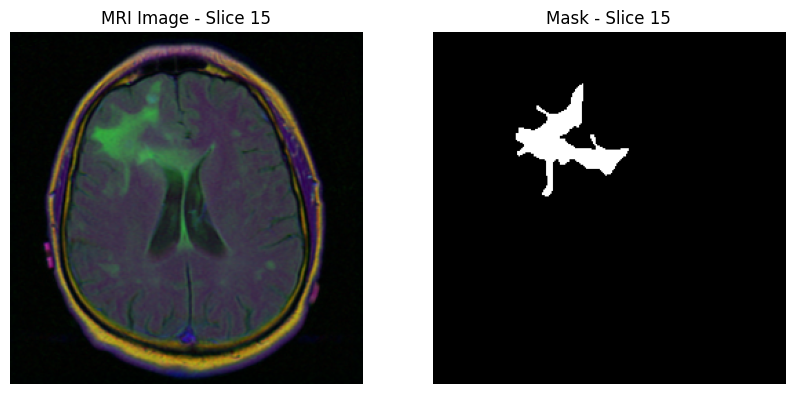

In [13]:
image_path2 = sample_patient / f"{sample_patient.name}_15.tif"
mask_path2 = sample_patient / f"{sample_patient.name}_15_mask.tif"

image2 = cv2.imread(str(image_path2))
mask2 = cv2.imread(str(mask_path2), cv2.IMREAD_GRAYSCALE)

print(f"Unique values ​​of clipping mask 15: {np.unique(mask2)}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(cv2.cvtColor(image2, cv2.COLOR_BGR2RGB))
axes[0].set_title("MRI Image - Slice 15")
axes[0].axis("off")

axes[1].imshow(mask2, cmap="gray")
axes[1].set_title("Mask - Slice 15")
axes[1].axis("off")

plt.show()

In [14]:
total_slices = 0
tumor_slices = 0
no_tumor_slices = 0

for patient_folder in patient_folders:
    mask_files = [f for f in os.listdir(patient_folder) if f.endswith("_mask.tif")]
    
    for mask_file in mask_files:
        mask_full_path = patient_folder / mask_file
        mask_img = cv2.imread(str(mask_full_path), cv2.IMREAD_GRAYSCALE)
        
        total_slices += 1
        if np.max(mask_img) > 0:
            tumor_slices += 1
        else:
            no_tumor_slices += 1

print(f"Total number of slices: {total_slices}")
print(f"Slices with tumors: {tumor_slices} ({tumor_slices/total_slices*100:.1f}%)")
print(f"Tumor-free slices: {no_tumor_slices} ({no_tumor_slices/total_slices*100:.1f}%)")

Total number of slices: 3929
Slices with tumors: 1373 (34.9%)
Tumor-free slices: 2556 (65.1%)


Minimum number of slices: 20
Maximum number of slices: 88
Average number of slices: 35.7
median: 33.0


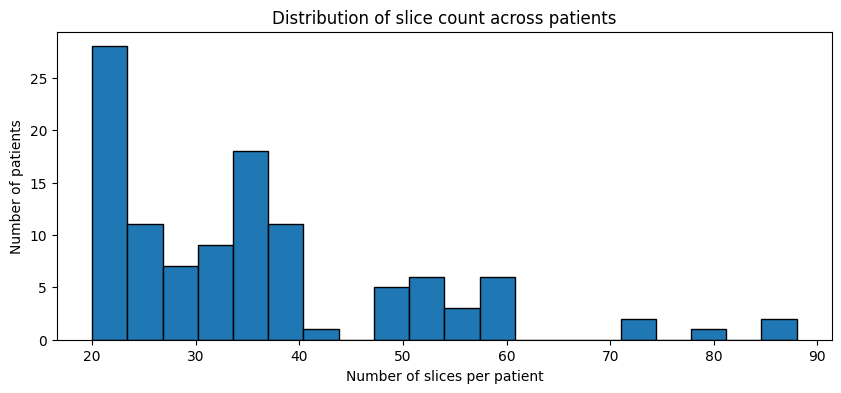

In [15]:
slice_counts = []

for patient_folder in patient_folders:
    mask_files = [f for f in os.listdir(patient_folder) if f.endswith("_mask.tif")]
    slice_counts.append(len(mask_files))

slice_counts = np.array(slice_counts)

print(f"Minimum number of slices: {slice_counts.min()}")
print(f"Maximum number of slices: {slice_counts.max()}")
print(f"Average number of slices: {slice_counts.mean():.1f}")
print(f"median: {np.median(slice_counts):.1f}")

plt.figure(figsize=(10, 4))
plt.hist(slice_counts, bins=20, edgecolor="black")
plt.xlabel("Number of slices per patient")
plt.ylabel("Number of patients")
plt.title("Distribution of slice count across patients")
plt.show()